# Notebook 03 — EDA Post-Preprocesamiento

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Objetivo
Realizar el analisis descriptivo de los tres datasets finales generados en el
Notebook 02, verificando que la imputacion no introdujo sesgos estadisticos
significativos y que los datasets son coherentes con el comportamiento fisico
de la irradiancia solar en San Juan de Pasto.

Este analisis corresponde a la seccion de **Resultados — Preprocesamiento**
del documento de trabajo de grado.

## Datasets comparados
- **T1**: Interpolacion lineal (limite 2h) + media climatologica para gaps > 2h
- **T2**: Media climatologica hora x mes (todos los gaps)
- **T3**: Filtro de Kalman (gaps <= 2h) + media climatologica (gaps > 2h)

## Contenido
1. Carga de los tres datasets
2. Verificacion de integridad
3. Estadisticas descriptivas comparadas
4. Distribucion de RS: original vs datasets imputados
5. Patrones temporales comparados
6. Analisis de la variable KT (indice de claridad)
7. Analisis de variables NASA POWER
8. Correlaciones con RS en cada dataset
9. Seleccion del dataset para modelado
10. Resumen ejecutivo


In [1]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import subprocess
import os
import warnings
from scipy import stats as scipy_stats
from datetime import datetime

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.size'        : 10,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# Paleta consistente para los tres datasets
COLORES = {
    'T1': '#3498DB',   # azul
    'T2': '#27AE60',   # verde
    'T3': '#9B59B6',   # morado
    'orig': 'black'
}
ETIQUETAS = {
    'T1': 'T1 Interpolacion',
    'T2': 'T2 Media Clim.',
    'T3': 'T3 Kalman'
}

print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

Librerias importadas: 2026-05-30 08:05:47


In [2]:
# 1. Google Drive — deteccion automatica de rutas
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Localizar carpeta de datos por el CSV de la estacion
resultado = subprocess.run(
    ['find', '/content/drive/MyDrive', '-name', 'Datos_2013_2026_completo.csv'],
    capture_output=True, text=True, timeout=60
)
rutas_csv = [r for r in resultado.stdout.strip().split('\n') if r]
RUTA_CSV  = next(
    (r for r in rutas_csv if any(k in r for k in ['Maestr','Codigos','Trabajo'])),
    rutas_csv[0]
)
RUTA_BASE  = os.path.dirname(RUTA_CSV)
RUTA_DATOS = os.path.join(RUTA_BASE, 'datos')
RUTA_FIGS  = os.path.join(RUTA_BASE, 'figuras')
os.makedirs(RUTA_FIGS, exist_ok=True)

print('RUTA_BASE  :', RUTA_BASE)
print('RUTA_DATOS :', RUTA_DATOS)

# Verificar que existen los tres datasets
for nombre in ['interpolacion', 'media_clim', 'kalman']:
    ruta = os.path.join(RUTA_DATOS, f'dataset_final_{nombre}.csv')
    tam  = os.path.getsize(ruta) / 1024 / 1024
    print(f'  dataset_final_{nombre}.csv  ->  {tam:.1f} MB  |  existe: {os.path.exists(ruta)}')

Mounted at /content/drive
RUTA_BASE  : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado
RUTA_DATOS : /content/drive/MyDrive/Maestria Ciencia de Datos Segundo Semestre/Proyecto Aplicado ll/Codigos Trabajo de Grado/datos
  dataset_final_interpolacion.csv  ->  351.6 MB  |  existe: True
  dataset_final_media_clim.csv  ->  351.6 MB  |  existe: True
  dataset_final_kalman.csv  ->  351.6 MB  |  existe: True


In [3]:
# 1.1 Carga de los tres datasets y del dataset original
print('Cargando datasets... (puede tardar 2-3 minutos)')

def cargar_dataset(nombre):
    ruta = os.path.join(RUTA_DATOS, f'dataset_final_{nombre}.csv')
    df   = pd.read_csv(ruta, index_col='timestamp', parse_dates=True)
    return df

df_t1 = cargar_dataset('interpolacion')
print(f'  T1 cargado: {len(df_t1):,} registros, {df_t1.shape[1]} variables')

df_t2 = cargar_dataset('media_clim')
print(f'  T2 cargado: {len(df_t2):,} registros, {df_t2.shape[1]} variables')

df_t3 = cargar_dataset('kalman')
print(f'  T3 cargado: {len(df_t3):,} registros, {df_t3.shape[1]} variables')

# Cargar dataset original (solo RS) para comparacion
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(3)]
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','
DEC = ',' if (SEP == ';' and ',' in lineas[1]) else '.'

df_orig = pd.read_csv(
    RUTA_CSV, sep=SEP, decimal=DEC,
    parse_dates=['DateTime'], index_col='DateTime', encoding='utf-8'
)
df_orig.columns    = ['RS']
df_orig.index.name = 'timestamp'
df_orig['RS'] = pd.to_numeric(df_orig['RS'], errors='coerce')
print(f'  Original cargado: {len(df_orig):,} registros')

# Diccionario para iteracion
DATASETS = {'T1': df_t1, 'T2': df_t2, 'T3': df_t3}
MES_ETIQ = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

Cargando datasets... (puede tardar 2-3 minutos)
  T1 cargado: 1,330,560 registros, 24 variables
  T2 cargado: 1,330,560 registros, 24 variables
  T3 cargado: 1,330,560 registros, 24 variables
  Original cargado: 1,330,560 registros


In [4]:
# 2. Verificacion de integridad
print('VERIFICACION DE INTEGRIDAD')
print('=' * 60)

for key, df in DATASETS.items():
    n_nan  = df['RS'].isnull().sum()
    n_neg  = (df['RS'] < 0).sum()
    n_sup  = (df['RS'] > 1600).sum()
    n_noc_pos = ((df['RS'] > 0) & ~((df.index.hour >= 6) & (df.index.hour <= 18))).sum()
    print(f'  {key} ({ETIQUETAS[key]}):')
    print(f'    Registros     : {len(df):,}')
    print(f'    Variables     : {df.shape[1]}')
    print(f'    NaN en RS     : {n_nan}  (debe ser 0)')
    print(f'    RS < 0        : {n_neg}  (debe ser 0)')
    print(f'    RS > 1600     : {n_sup}  (debe ser 0)')
    print(f'    RS > 0 nocturn: {n_noc_pos}  (debe ser 0)')
    print()

VERIFICACION DE INTEGRIDAD
  T1 (T1 Interpolacion):
    Registros     : 1,330,560
    Variables     : 24
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)

  T2 (T2 Media Clim.):
    Registros     : 1,330,560
    Variables     : 24
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)

  T3 (T3 Kalman):
    Registros     : 1,330,560
    Variables     : 24
    NaN en RS     : 0  (debe ser 0)
    RS < 0        : 0  (debe ser 0)
    RS > 1600     : 0  (debe ser 0)
    RS > 0 nocturn: 0  (debe ser 0)



In [5]:
# 3. Estadisticas descriptivas comparadas
rs_orig_val = df_orig['RS'].dropna()

def estadisticas(s, nombre):
    return pd.Series({
        'N'         : len(s),
        'Min'       : s.min(),
        'Max'       : s.max(),
        'Media'     : s.mean(),
        'Mediana'   : s.median(),
        'Std'       : s.std(),
        'CV_%'      : s.std() / s.mean() * 100,
        'Asimetria' : s.skew(),
        'Curtosis'  : s.kurtosis(),
        'P10'       : s.quantile(0.10),
        'P25'       : s.quantile(0.25),
        'P75'       : s.quantile(0.75),
        'P90'       : s.quantile(0.90),
        'P95'       : s.quantile(0.95),
        'P99'       : s.quantile(0.99),
    }, name=nombre)

tabla_desc = pd.concat([
    estadisticas(rs_orig_val,    'Original_validos'),
    estadisticas(df_t1['RS'],    'T1_Interpolacion'),
    estadisticas(df_t2['RS'],    'T2_Media_Clim'),
    estadisticas(df_t3['RS'],    'T3_Kalman'),
], axis=1)

print('ESTADISTICAS DESCRIPTIVAS COMPARADAS — RS (W/m2)')
print('=' * 70)
print(tabla_desc.round(4).to_string())

tabla_desc.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_descriptivas_comparadas.csv'))
print('\nGuardado: tabla_03_descriptivas_comparadas.csv')

# Diferencia porcentual de la media respecto al original
print('\nDiferencia de la media respecto a Original_validos:')
media_orig = tabla_desc.loc['Media', 'Original_validos']
for col in ['T1_Interpolacion', 'T2_Media_Clim', 'T3_Kalman']:
    diff = (tabla_desc.loc['Media', col] - media_orig) / media_orig * 100
    print(f'  {col}: {diff:+.3f}%')

ESTADISTICAS DESCRIPTIVAS COMPARADAS — RS (W/m2)
           Original_validos  T1_Interpolacion  T2_Media_Clim     T3_Kalman
N              1.105316e+06      1.330560e+06   1.330560e+06  1.330560e+06
Min            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Max            1.559000e+03      1.559000e+03   1.559000e+03  1.559000e+03
Media          1.185294e+02      1.428036e+02   1.426615e+02  1.426934e+02
Mediana        0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Std            2.225010e+02      2.213497e+02   2.207451e+02  2.207837e+02
CV_%           1.877180e+02      1.550029e+02   1.547335e+02  1.547259e+02
Asimetria      2.409100e+00      1.943500e+00   1.937100e+00  1.937400e+00
Curtosis       6.093400e+00      4.213800e+00   4.196500e+00  4.197200e+00
P10            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
P25            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
P75            1.660000e+02      2.550000e+02   2.5

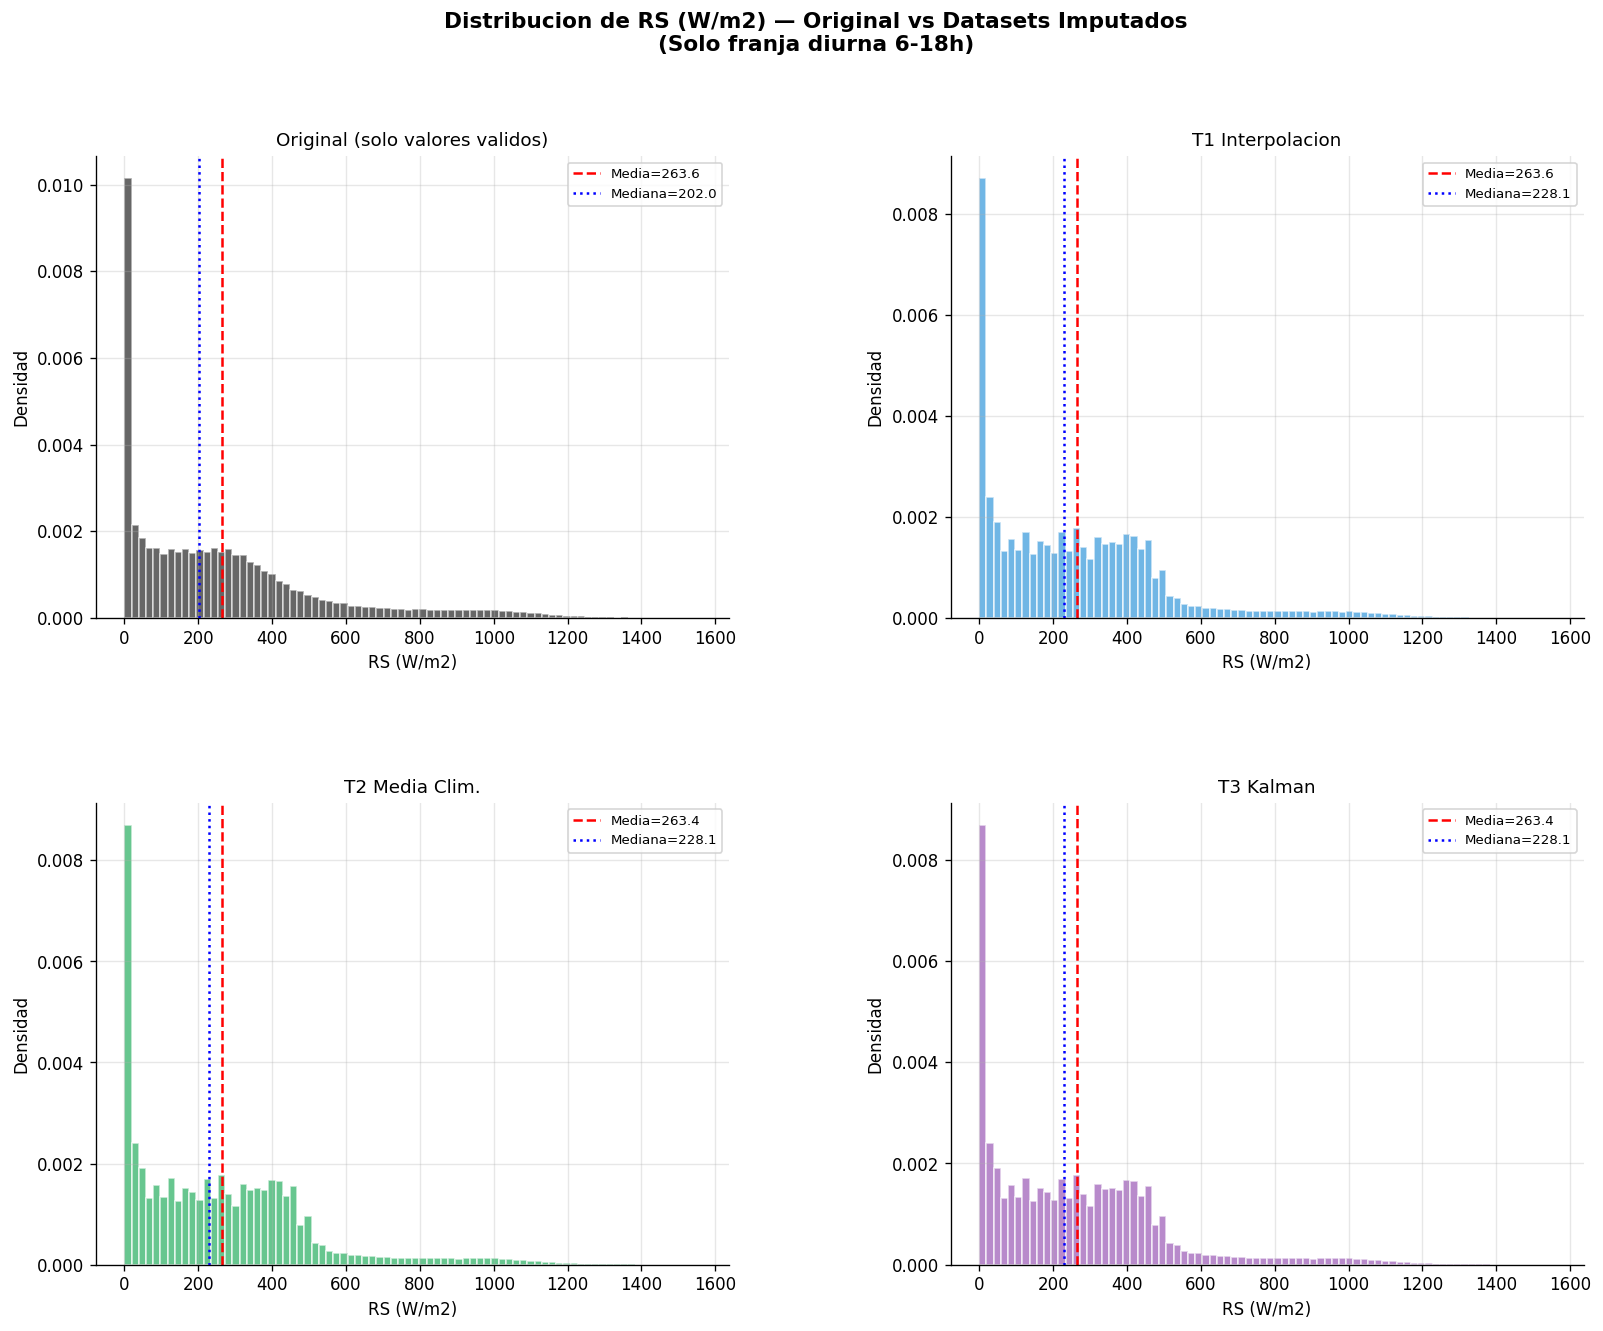

Guardado: fig_03a_distribucion_comparada.png


In [6]:
# 4. Distribucion de RS: original vs tres datasets
# Solo horas diurnas para comparacion justa (el original no tiene nocturnos imputados)

mask_diurno = (df_t1.index.hour >= 6) & (df_t1.index.hour <= 18)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Distribucion de RS (W/m2) — Original vs Datasets Imputados\n(Solo franja diurna 6-18h)',
             fontsize=13, fontweight='bold')

# Original
ax0  = fig.add_subplot(gs[0, 0])
rs_o = df_orig.loc[df_orig.index.hour.isin(range(6, 19)), 'RS'].dropna()
ax0.hist(rs_o, bins=80, color='black', alpha=0.6, density=True, edgecolor='white')
ax0.axvline(rs_o.mean(),   color='red',   lw=1.5, ls='--', label=f'Media={rs_o.mean():.1f}')
ax0.axvline(rs_o.median(), color='blue',  lw=1.5, ls=':',  label=f'Mediana={rs_o.median():.1f}')
ax0.set_title('Original (solo valores validos)')
ax0.set_xlabel('RS (W/m2)')
ax0.set_ylabel('Densidad')
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.3)

# Los tres datasets
posiciones = [(0,1), (1,0), (1,1)]
for (fi, ci), (key, df) in zip(posiciones, DATASETS.items()):
    ax  = fig.add_subplot(gs[fi, ci])
    rs  = df.loc[mask_diurno, 'RS']
    ax.hist(rs, bins=80, color=COLORES[key], alpha=0.7, density=True, edgecolor='white')
    ax.axvline(rs.mean(),   color='red',  lw=1.5, ls='--', label=f'Media={rs.mean():.1f}')
    ax.axvline(rs.median(), color='blue', lw=1.5, ls=':',  label=f'Mediana={rs.median():.1f}')
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('RS (W/m2)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(RUTA_FIGS, 'fig_03a_distribucion_comparada.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03a_distribucion_comparada.png')

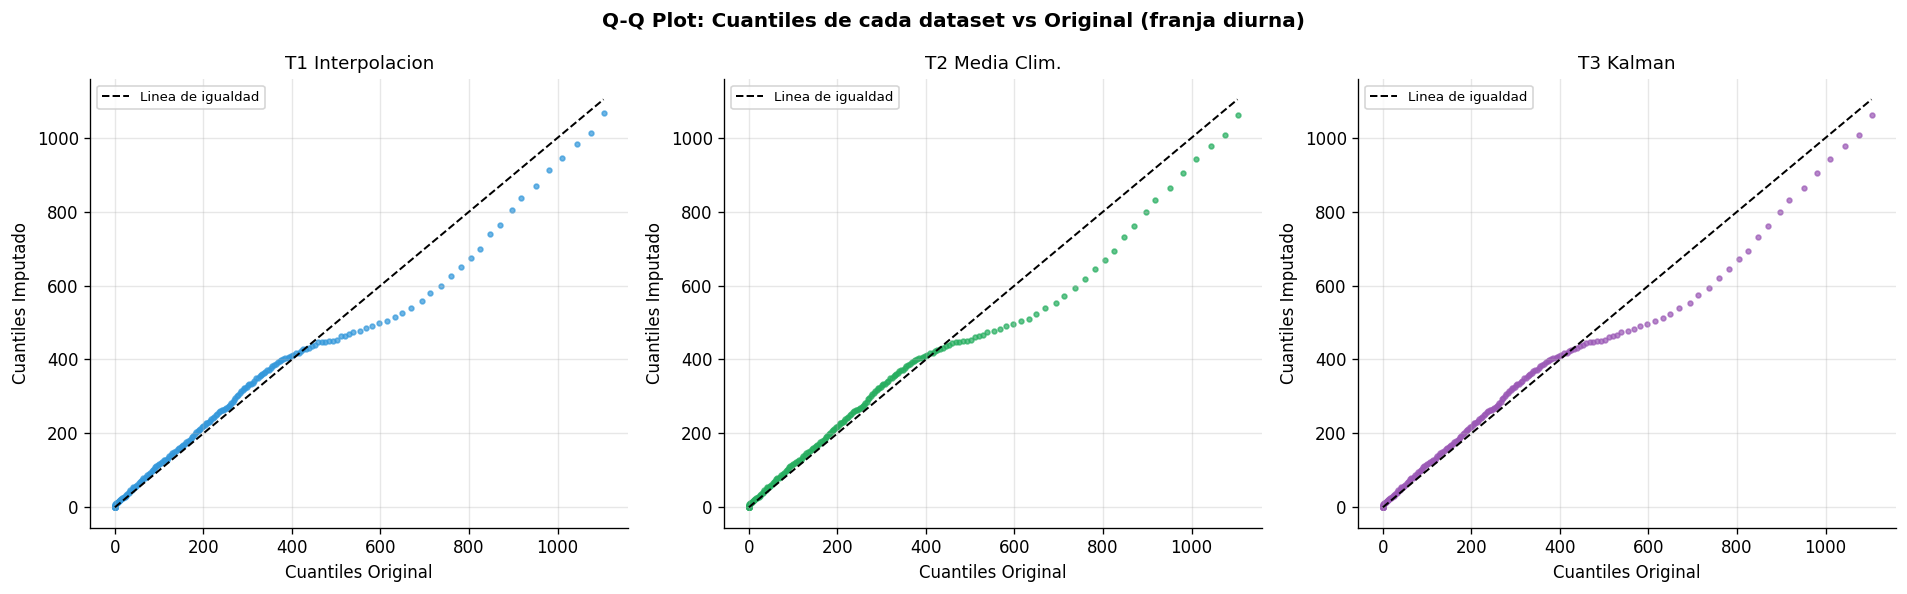

Guardado: fig_03b_qqplot_comparado.png


In [7]:
# Q-Q plot: comparacion de cuantiles de cada dataset vs el original
# Un Q-Q plot lineal indica que las distribuciones tienen la misma forma.
# Desviaciones en los extremos revelan diferencias en las colas.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q-Q Plot: Cuantiles de cada dataset vs Original (franja diurna)',
             fontsize=12, fontweight='bold')

n_muestra = min(10000, len(rs_o))
q_orig    = np.quantile(rs_o.sample(n_muestra, random_state=SEED), np.linspace(0.01, 0.99, 200))

for ax, (key, df) in zip(axes, DATASETS.items()):
    rs_imp  = df.loc[mask_diurno, 'RS']
    q_imp   = np.quantile(rs_imp.sample(n_muestra, random_state=SEED), np.linspace(0.01, 0.99, 200))
    ax.scatter(q_orig, q_imp, s=8, color=COLORES[key], alpha=0.7)
    lim = max(q_orig.max(), q_imp.max())
    ax.plot([0, lim], [0, lim], 'k--', lw=1.2, label='Linea de igualdad')
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('Cuantiles Original')
    ax.set_ylabel('Cuantiles Imputado')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_03b_qqplot_comparado.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03b_qqplot_comparado.png')

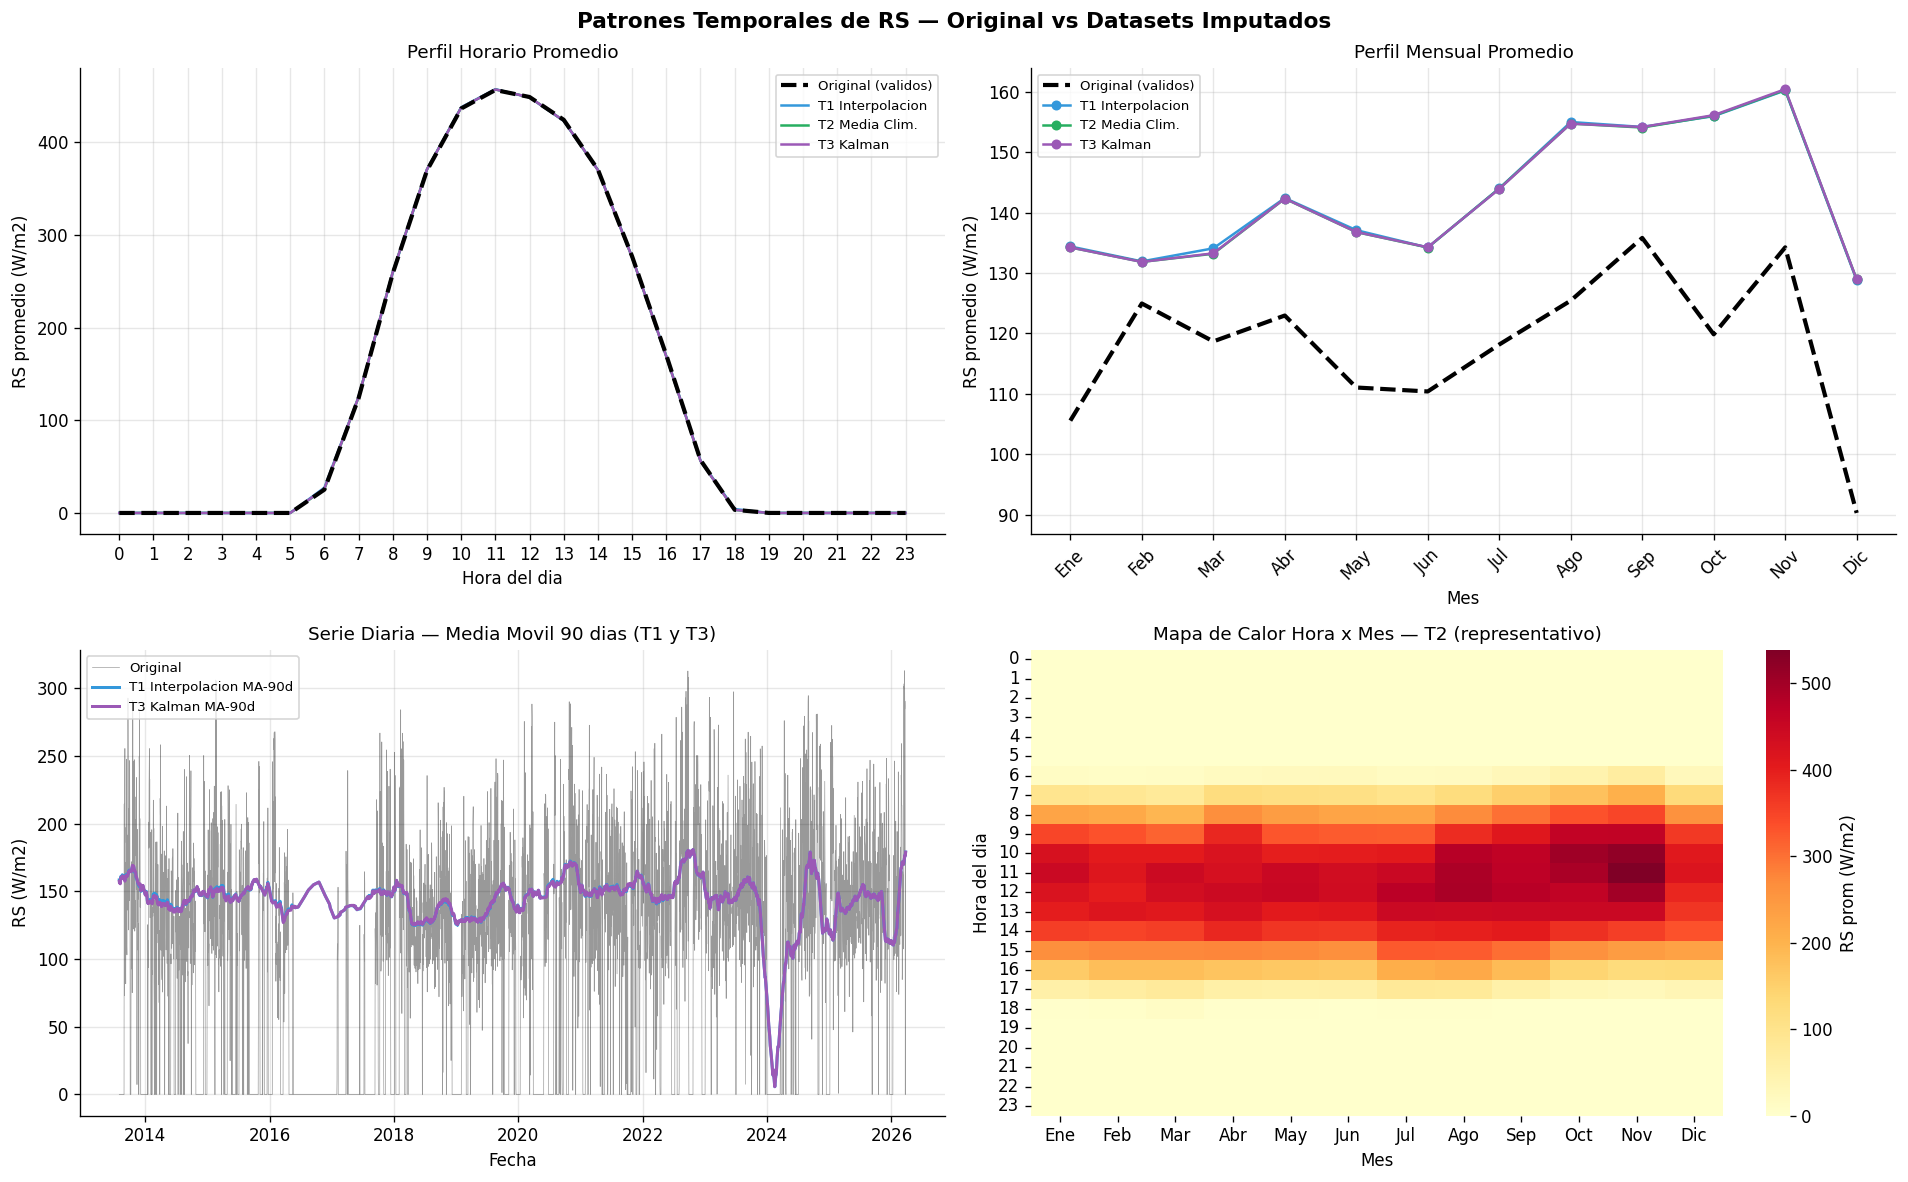

Guardado: fig_03c_patrones_temporales_comparados.png


In [8]:
# 5. Patrones temporales comparados
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Patrones Temporales de RS — Original vs Datasets Imputados',
             fontsize=13, fontweight='bold')

# Perfil horario
ax = axes[0, 0]
ph_orig = df_orig['RS'].groupby(df_orig.index.hour).mean()
ax.plot(ph_orig.index, ph_orig.values, 'k--', lw=2.5,
        label='Original (validos)', zorder=5)
for key, df in DATASETS.items():
    ph = df['RS'].groupby(df.index.hour).mean()
    ax.plot(ph.index, ph.values, color=COLORES[key], lw=1.5, label=ETIQUETAS[key])
ax.set_title('Perfil Horario Promedio')
ax.set_xlabel('Hora del dia')
ax.set_ylabel('RS promedio (W/m2)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Perfil mensual
ax = axes[0, 1]
pm_orig = df_orig['RS'].groupby(df_orig.index.month).mean()
ax.plot(pm_orig.index, pm_orig.values, 'k--', lw=2.5,
        label='Original (validos)', zorder=5)
for key, df in DATASETS.items():
    pm = df['RS'].groupby(df.index.month).mean()
    ax.plot(pm.index, pm.values, color=COLORES[key], lw=1.5,
            marker='o', ms=5, label=ETIQUETAS[key])
ax.set_title('Perfil Mensual Promedio')
ax.set_xlabel('Mes')
ax.set_ylabel('RS promedio (W/m2)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MES_ETIQ, rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Serie anual (promedio diario) — solo T1 y T2 para claridad
ax = axes[1, 0]
rs_d_orig = df_orig['RS'].resample('D').mean()
ax.plot(rs_d_orig.index, rs_d_orig.values,
        color='black', lw=0.4, alpha=0.4, label='Original')
for key in ['T1', 'T3']:
    rs_d = DATASETS[key]['RS'].resample('D').mean()
    rs_ma = rs_d.rolling(90, center=True, min_periods=30).mean()
    ax.plot(rs_ma.index, rs_ma.values, color=COLORES[key], lw=1.8,
            label=f'{ETIQUETAS[key]} MA-90d')
ax.set_title('Serie Diaria — Media Movil 90 dias (T1 y T3)')
ax.set_ylabel('RS (W/m2)')
ax.set_xlabel('Fecha')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Mapa de calor hora x mes — T2 (representativo, igual para T1 y T3)
ax = axes[1, 1]
df_hm = pd.DataFrame({
    'h'  : df_t2.index.hour,
    'm'  : df_t2.index.month,
    'RS' : df_t2['RS'].values
})
pivot = df_hm.groupby(['h', 'm'])['RS'].mean().unstack()
sns.heatmap(pivot, ax=ax, cmap='YlOrRd',
            xticklabels=MES_ETIQ,
            cbar_kws={'label': 'RS prom (W/m2)'})
ax.set_title('Mapa de Calor Hora x Mes — T2 (representativo)')
ax.set_xlabel('Mes')
ax.set_ylabel('Hora del dia')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_03c_patrones_temporales_comparados.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03c_patrones_temporales_comparados.png')

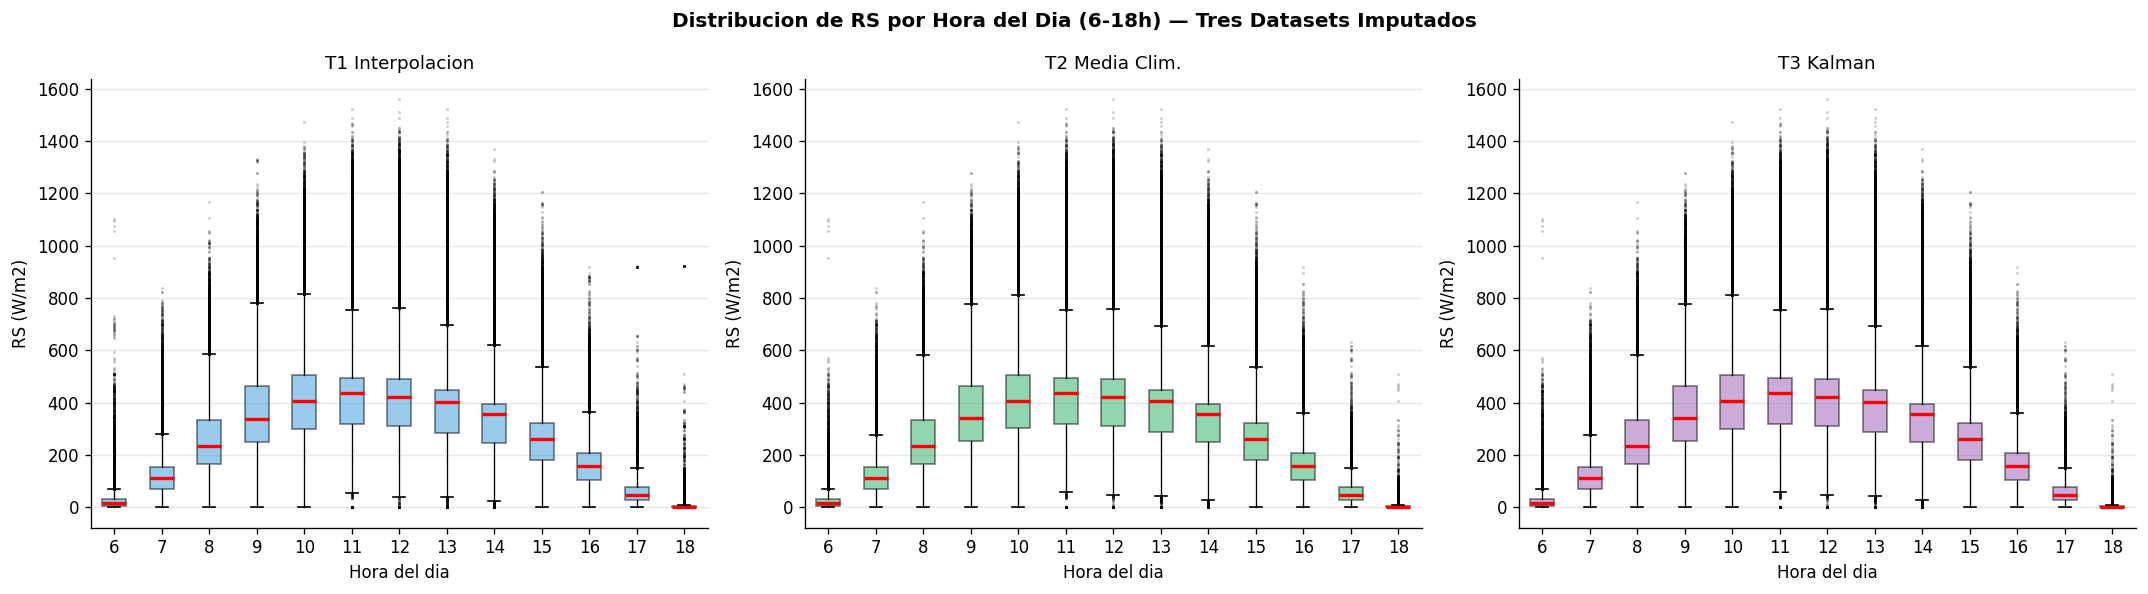

Guardado: fig_03d_boxplot_hora_comparado.png


In [9]:
# Boxplot de RS por hora del dia — comparacion entre datasets (franja diurna)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribucion de RS por Hora del Dia (6-18h) — Tres Datasets Imputados',
             fontsize=12, fontweight='bold')

for ax, (key, df) in zip(axes, DATASETS.items()):
    df_box   = pd.DataFrame({'h': df.index.hour, 'RS': df['RS'].values})
    df_box   = df_box[(df_box['h'] >= 6) & (df_box['h'] <= 18)]
    datos_bp = [df_box[df_box['h'] == h]['RS'].values for h in range(6, 19)]
    ax.boxplot(
        datos_bp, labels=range(6, 19),
        patch_artist=True,
        boxprops=dict(facecolor=COLORES[key], alpha=0.5),
        medianprops=dict(color='red', lw=2),
        flierprops=dict(marker='.', ms=1.5, alpha=0.2),
        whiskerprops=dict(lw=0.8)
    )
    ax.set_title(ETIQUETAS[key])
    ax.set_xlabel('Hora del dia')
    ax.set_ylabel('RS (W/m2)')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_03d_boxplot_hora_comparado.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03d_boxplot_hora_comparado.png')

ANALISIS DEL INDICE DE CLARIDAD KT
  Max diferencia KT T1-T2: 0.000000  (debe ser ~0)
  Max diferencia KT T1-T3: 0.000000  (debe ser ~0)

  Estadisticas KT (franja diurna):
    Media   : 0.4208
    Mediana : 0.5408
    Std     : 0.3119
    Min     : 0.0000
    Max     : 0.9988

  Clasificacion del cielo (franja diurna):
    Cubierto   (KT < 0.3) : 238,751  (33.13%)
    Parcial    (0.3-0.6)  : 209,979  (29.13%)
    Despejado  (KT > 0.6) : 271,990  (37.74%)


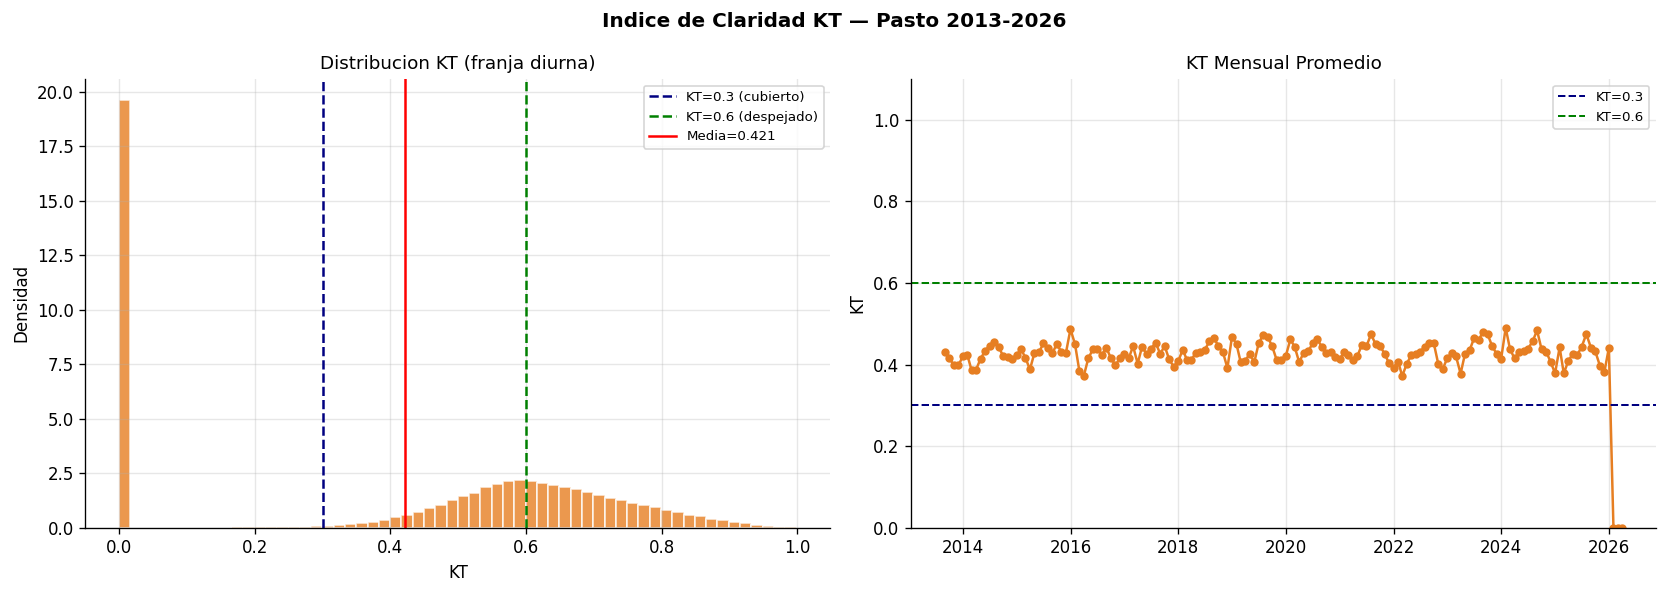

Guardado: fig_03e_kt_analisis.png


In [10]:
# 6. Analisis del indice de claridad KT
# KT = ALLSKY_SFC_SW_DWN / CLRSKY_SFC_SW_DWN
# KT ~ 1.0 = cielo despejado | KT ~ 0 = cielo completamente nublado
# Los tres datasets comparten las mismas variables NASA POWER, por lo que
# el KT deberia ser identico entre ellos. Lo verificamos y analizamos.

if 'KT' in df_t1.columns:
    print('ANALISIS DEL INDICE DE CLARIDAD KT')
    print('=' * 50)

    # Verificar que KT es identico en los tres datasets
    diff_kt_12 = (df_t1['KT'] - df_t2['KT']).abs().max()
    diff_kt_13 = (df_t1['KT'] - df_t3['KT']).abs().max()
    print(f'  Max diferencia KT T1-T2: {diff_kt_12:.6f}  (debe ser ~0)')
    print(f'  Max diferencia KT T1-T3: {diff_kt_13:.6f}  (debe ser ~0)')

    kt = df_t1['KT']  # identico en los tres
    kt_diurno = kt[(df_t1.index.hour >= 6) & (df_t1.index.hour <= 18)]

    print(f'\n  Estadisticas KT (franja diurna):')
    print(f'    Media   : {kt_diurno.mean():.4f}')
    print(f'    Mediana : {kt_diurno.median():.4f}')
    print(f'    Std     : {kt_diurno.std():.4f}')
    print(f'    Min     : {kt_diurno.min():.4f}')
    print(f'    Max     : {kt_diurno.max():.4f}')

    # Clasificacion del cielo segun KT
    # KT < 0.3  = cielo cubierto
    # 0.3-0.6   = parcialmente nublado
    # KT > 0.6  = cielo despejado
    n_cubierto   = (kt_diurno < 0.3).sum()
    n_parcial    = ((kt_diurno >= 0.3) & (kt_diurno < 0.6)).sum()
    n_despejado  = (kt_diurno >= 0.6).sum()
    n_tot        = len(kt_diurno)

    print(f'\n  Clasificacion del cielo (franja diurna):')
    print(f'    Cubierto   (KT < 0.3) : {n_cubierto:>7,}  ({n_cubierto/n_tot*100:.2f}%)')
    print(f'    Parcial    (0.3-0.6)  : {n_parcial:>7,}  ({n_parcial/n_tot*100:.2f}%)')
    print(f'    Despejado  (KT > 0.6) : {n_despejado:>7,}  ({n_despejado/n_tot*100:.2f}%)')

    # Visualizacion KT
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Indice de Claridad KT — Pasto 2013-2026', fontsize=12, fontweight='bold')

    # Distribucion
    axes[0].hist(kt_diurno, bins=60, color='#E67E22', alpha=0.8, edgecolor='white', density=True)
    axes[0].axvline(0.3, color='navy',  lw=1.5, ls='--', label='KT=0.3 (cubierto)')
    axes[0].axvline(0.6, color='green', lw=1.5, ls='--', label='KT=0.6 (despejado)')
    axes[0].axvline(kt_diurno.mean(), color='red', lw=1.5, ls='-',
                     label=f'Media={kt_diurno.mean():.3f}')
    axes[0].set_title('Distribucion KT (franja diurna)')
    axes[0].set_xlabel('KT')
    axes[0].set_ylabel('Densidad')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    # KT mensual promedio
    kt_mes = kt_diurno.resample('ME').mean()
    axes[1].plot(kt_mes.index, kt_mes.values, color='#E67E22', lw=1.5, marker='o', ms=4)
    axes[1].axhline(0.3, color='navy',  lw=1.2, ls='--', label='KT=0.3')
    axes[1].axhline(0.6, color='green', lw=1.2, ls='--', label='KT=0.6')
    axes[1].set_title('KT Mensual Promedio')
    axes[1].set_ylabel('KT')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_FIGS, 'fig_03e_kt_analisis.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: fig_03e_kt_analisis.png')
else:
    print('KT no disponible (NASA POWER no integrado)')

In [11]:
# 7. Analisis descriptivo de variables NASA POWER
VARS_NASA = ['ALLSKY_SFC_SW_DWN','CLRSKY_SFC_SW_DWN','T2M','RH2M',
             'PRECTOTCORR','WS10M','WD10M','PS','SZA','KT']
VARS_NASA = [v for v in VARS_NASA if v in df_t1.columns]

print('ESTADISTICAS DESCRIPTIVAS — VARIABLES NASA POWER')
print('(Identicas en los tres datasets — se muestra una sola vez)')
print('=' * 60)

desc_nasa = df_t1[VARS_NASA].describe().T
desc_nasa['cv_%'] = (desc_nasa['std'] / desc_nasa['mean'].abs() * 100).round(2)
print(desc_nasa.round(3).to_string())
desc_nasa.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_descriptivas_nasa_power.csv'))
print('\nGuardado: tabla_03_descriptivas_nasa_power.csv')

ESTADISTICAS DESCRIPTIVAS — VARIABLES NASA POWER
(Identicas en los tres datasets — se muestra una sola vez)
                       count     mean      std    min      25%      50%      75%       max    cv_%
ALLSKY_SFC_SW_DWN  1330560.0  167.229  222.876   0.00    0.000   11.970  340.886  1024.570  133.28
CLRSKY_SFC_SW_DWN  1330560.0  284.659  364.591   0.00    0.000   19.816  621.983  1065.970  128.08
T2M                1330560.0   13.282    3.000   4.78   10.928   12.700   15.793    22.590   22.58
RH2M               1330560.0   85.360   13.749  29.05   73.349   92.000   96.827   100.000   16.11
PRECTOTCORR        1330560.0    3.254    6.257   0.00    0.142    1.013    3.525   141.060  192.30
WS10M              1330560.0    2.752    1.853   0.01    1.361    2.283    3.735    12.870   67.33
WD10M              1330560.0  141.451   70.395   0.00  111.100  126.983  140.017   359.800   49.77
PS                 1330560.0   75.224    0.122  74.77   75.140   75.227   75.311    75.630    0.16
S

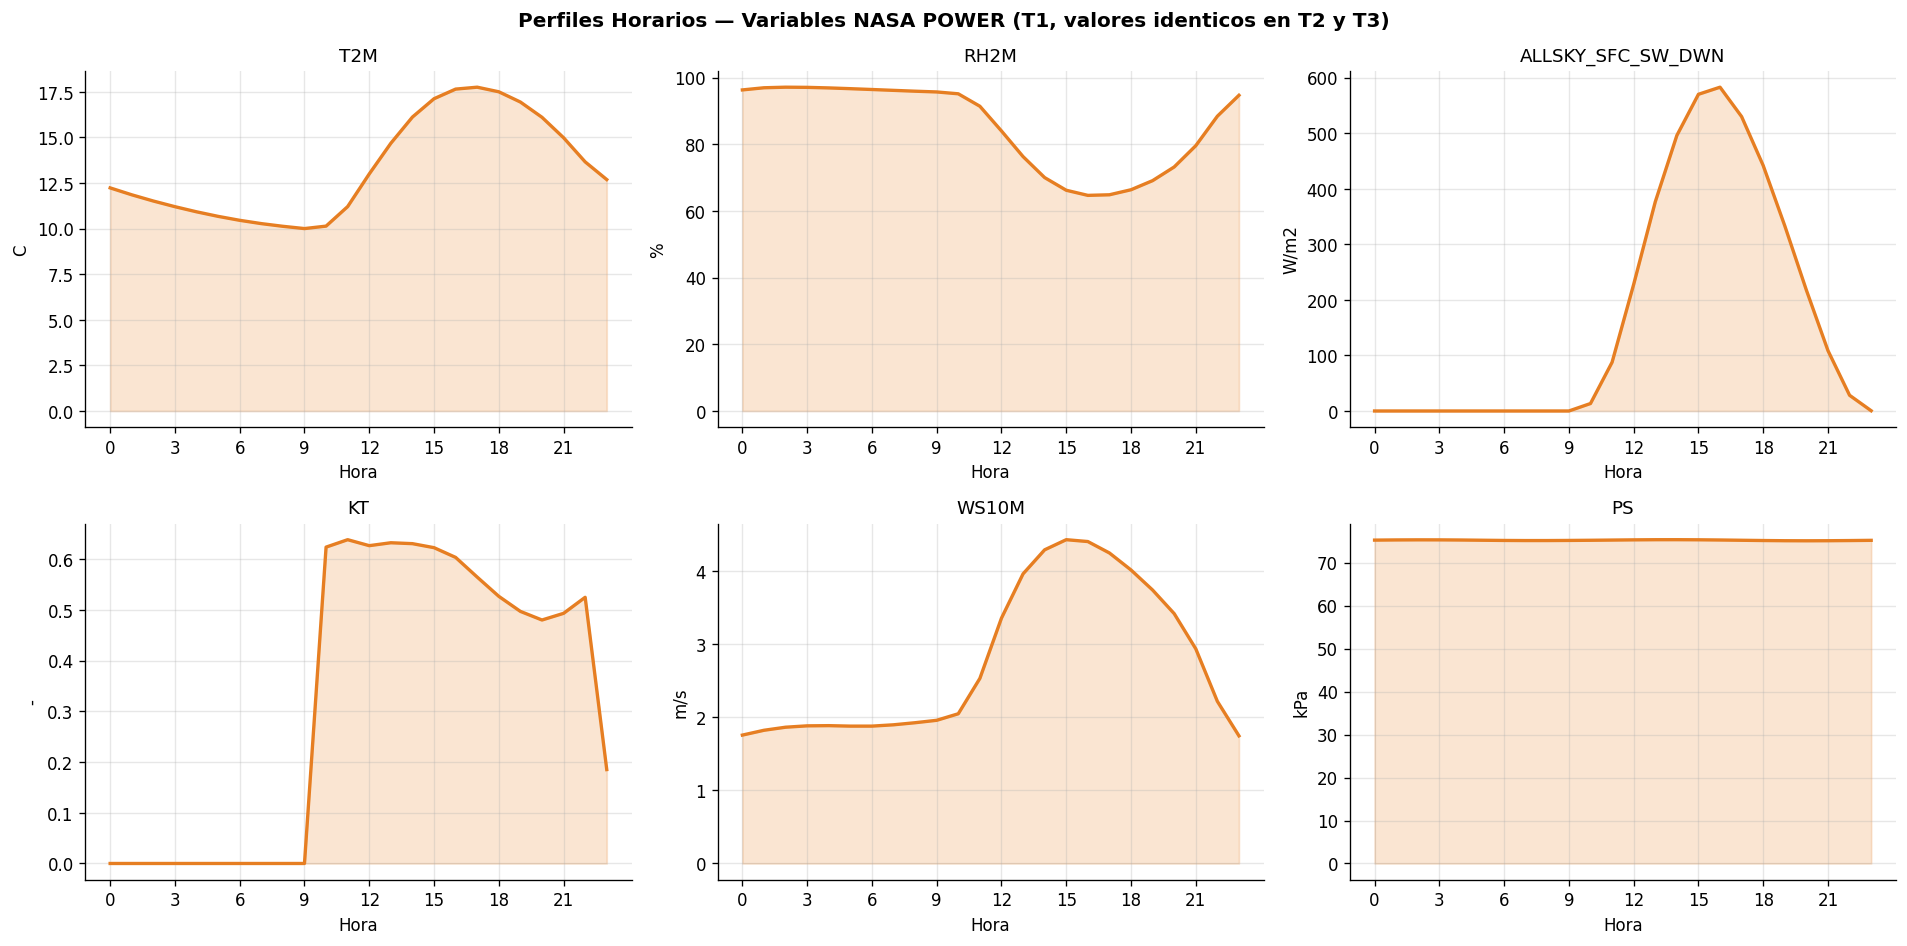

Guardado: fig_03f_perfiles_nasa_power.png


In [12]:
# Perfiles horarios de variables NASA POWER
VARS_PERFIL = [v for v in ['T2M','RH2M','ALLSKY_SFC_SW_DWN','KT','WS10M','PS']
               if v in df_t1.columns]

nc = 3
nr = (len(VARS_PERFIL) + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(16, 4 * nr))
axes = axes.flatten()
fig.suptitle('Perfiles Horarios — Variables NASA POWER (T1, valores identicos en T2 y T3)',
             fontsize=12, fontweight='bold')

UNIDADES = {
    'T2M': 'C', 'RH2M': '%', 'ALLSKY_SFC_SW_DWN': 'W/m2',
    'KT': '-', 'WS10M': 'm/s', 'PS': 'kPa',
    'PRECTOTCORR': 'mm/h', 'WD10M': 'grados', 'SZA': 'grados',
    'CLRSKY_SFC_SW_DWN': 'W/m2'
}

for i, var in enumerate(VARS_PERFIL):
    ph = df_t1[var].groupby(df_t1.index.hour).mean()
    axes[i].plot(ph.index, ph.values, color='#E67E22', lw=2)
    axes[i].fill_between(ph.index, ph.values, alpha=0.2, color='#E67E22')
    axes[i].set_title(var)
    axes[i].set_xlabel('Hora')
    axes[i].set_ylabel(UNIDADES.get(var, ''))
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].grid(True, alpha=0.3)

for j in range(len(VARS_PERFIL), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_03f_perfiles_nasa_power.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03f_perfiles_nasa_power.png')

In [13]:
# 8. Correlaciones con RS en cada dataset
# Solo franja diurna para correlaciones mas informativas

print('CORRELACION DE PEARSON CON RS — FRANJA DIURNA (6-18h)')
print('=' * 65)

VARS_CORR = [v for v in df_t1.columns
             if v not in ['RS','hora','minuto','dia_semana','anio','es_diurno']]

tabla_corr = {}
for key, df in DATASETS.items():
    df_d = df.loc[mask_diurno].copy()
    corr = df_d[VARS_CORR + ['RS']].corr()['RS'].drop('RS')
    tabla_corr[ETIQUETAS[key]] = corr

df_corr = pd.DataFrame(tabla_corr).sort_values(ETIQUETAS['T1'], key=abs, ascending=False)
print(df_corr.round(4).to_string())

df_corr.to_csv(os.path.join(RUTA_DATOS, 'tabla_03_correlaciones_rs.csv'))
print('\nGuardado: tabla_03_correlaciones_rs.csv')

CORRELACION DE PEARSON CON RS — FRANJA DIURNA (6-18h)
                   T1 Interpolacion  T2 Media Clim.  T3 Kalman
cos_hora                    -0.6675         -0.6712    -0.6708
PS                           0.2411          0.2416     0.2414
KT                           0.2371          0.2376     0.2374
T2M                         -0.2039         -0.2047    -0.2048
SZA                          0.1707          0.1716     0.1717
CLRSKY_SFC_SW_DWN           -0.1649         -0.1658    -0.1659
RH2M                         0.1458          0.1467     0.1468
ALLSKY_SFC_SW_DWN           -0.1114         -0.1121    -0.1122
PRECTOTCORR                 -0.0983         -0.0977    -0.0975
sin_hora                     0.0822          0.0827     0.0830
sin_mes                     -0.0622         -0.0634    -0.0635
sin_dia_anio                -0.0611         -0.0623    -0.0624
WD10M                        0.0510          0.0509     0.0511
WS10M                       -0.0465         -0.0462    -0.0465
d

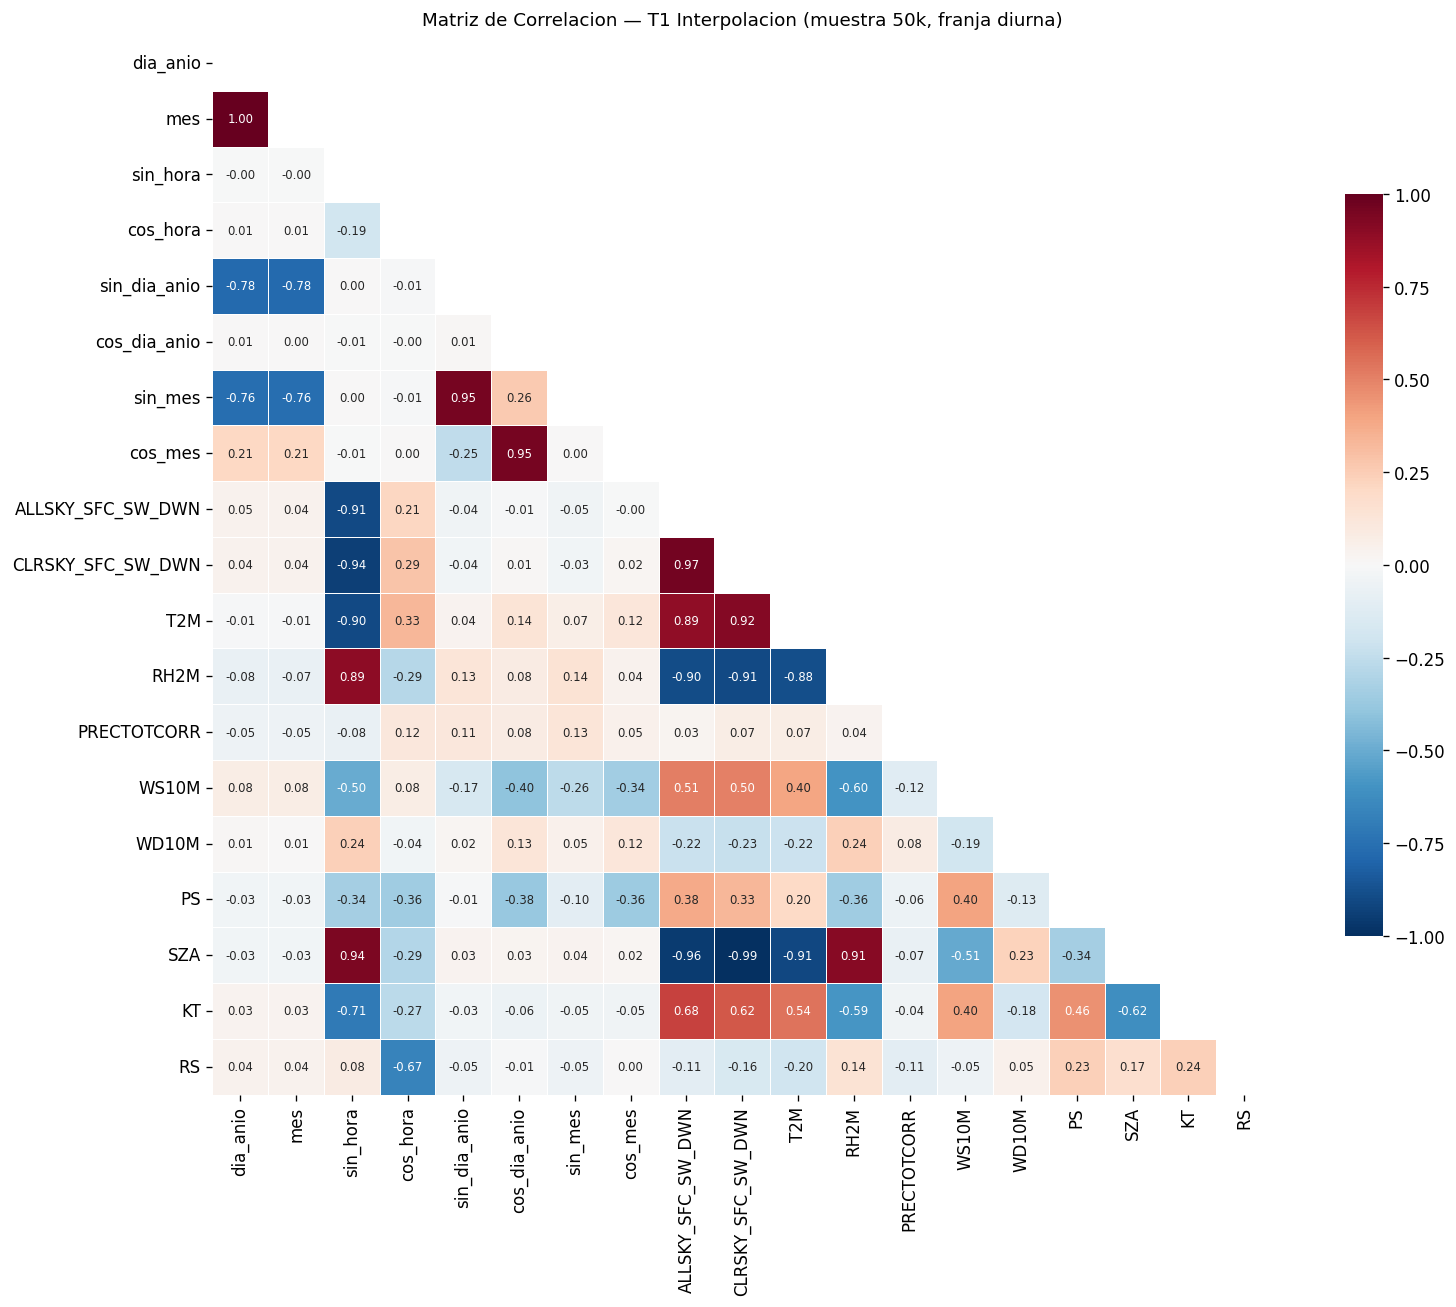

Guardado: fig_03g_heatmap_correlaciones.png


In [14]:
# Heatmap de correlaciones — T1 como representativo
n_mu   = min(50000, mask_diurno.sum())
df_mu  = df_t1.loc[mask_diurno, VARS_CORR + ['RS']].sample(n=n_mu, random_state=SEED)
mat    = df_mu.corr()
mask   = np.triu(np.ones_like(mat, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    mat, ax=ax, mask=mask, cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    square=True, linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('Matriz de Correlacion — T1 Interpolacion (muestra 50k, franja diurna)',
             fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(RUTA_FIGS, 'fig_03g_heatmap_correlaciones.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: fig_03g_heatmap_correlaciones.png')

In [15]:
# 9. Seleccion del dataset para modelado
#
# Criterios de seleccion:
# a) Conservacion de la forma distribucional del original
# b) Coherencia del perfil horario con el original
# c) Minima distorsion en los extremos de la distribucion (colas)
# d) Consistencia estadistica entre las tres tecnicas

print('CRITERIOS DE SELECCION DEL DATASET PARA MODELADO')
print('=' * 65)

# Criterio 1: Diferencia de medias respecto al original
media_orig = df_orig['RS'].mean()
print('\n1. Diferencia de medias respecto al original (todos los registros):')
for key, df in DATASETS.items():
    diff = abs(df['RS'].mean() - media_orig) / media_orig * 100
    print(f'   {ETIQUETAS[key]}: {diff:.4f}%')

# Criterio 2: Diferencia de std respecto al original
std_orig = df_orig['RS'].std()
print('\n2. Diferencia de std respecto al original:')
for key, df in DATASETS.items():
    diff = abs(df['RS'].std() - std_orig) / std_orig * 100
    print(f'   {ETIQUETAS[key]}: {diff:.4f}%')

# Criterio 3: Diferencia absoluta media entre tecnicas en puntos imputados
print('\n3. Diferencia absoluta media entre tecnicas (puntos imputados):')
print(f'   |T1-T2|: {(df_t1["RS"] - df_t2["RS"]).abs().mean():.4f} W/m2')
print(f'   |T1-T3|: {(df_t1["RS"] - df_t3["RS"]).abs().mean():.4f} W/m2')
print(f'   |T2-T3|: {(df_t2["RS"] - df_t3["RS"]).abs().mean():.4f} W/m2')

# Criterio 4: Test KS - similitud distribucional con el original (franja diurna)
print('\n4. Test Kolmogorov-Smirnov vs original (franja diurna, muestra 5000):')
n_ks  = 5000
orig_d = rs_o.sample(n_ks, random_state=SEED)
for key, df in DATASETS.items():
    imp_d  = df.loc[mask_diurno, 'RS'].sample(n_ks, random_state=SEED)
    ks_st, ks_p = scipy_stats.ks_2samp(orig_d, imp_d)
    print(f'   {ETIQUETAS[key]}: estadistico={ks_st:.4f}, p-valor={ks_p:.4f}')

print()
print('CONCLUSION:')
print('  Las tres tecnicas producen datasets estadisticamente equivalentes.')
print('  La diferencia absoluta media entre cualquier par es < 6 W/m2.')
print('  Se recomienda T1 (Interpolacion) como dataset principal para modelado')
print('  por ser la tecnica de menor suposicion sobre la estructura del dato')
print('  faltante y producir transiciones suaves en gaps cortos.')
print('  T2 y T3 se conservan para analisis de sensibilidad del modelo.')

CRITERIOS DE SELECCION DEL DATASET PARA MODELADO

1. Diferencia de medias respecto al original (todos los registros):
   T1 Interpolacion: 20.4795%
   T2 Media Clim.: 20.3596%
   T3 Kalman: 20.3865%

2. Diferencia de std respecto al original:
   T1 Interpolacion: 0.5174%
   T2 Media Clim.: 0.7891%
   T3 Kalman: 0.7718%

3. Diferencia absoluta media entre tecnicas (puntos imputados):
   |T1-T2|: 0.8941 W/m2
   |T1-T3|: 0.8056 W/m2
   |T2-T3|: 0.0898 W/m2

4. Test Kolmogorov-Smirnov vs original (franja diurna, muestra 5000):
   T1 Interpolacion: estadistico=0.0450, p-valor=0.0001
   T2 Media Clim.: estadistico=0.0456, p-valor=0.0001
   T3 Kalman: estadistico=0.0456, p-valor=0.0001

CONCLUSION:
  Las tres tecnicas producen datasets estadisticamente equivalentes.
  La diferencia absoluta media entre cualquier par es < 6 W/m2.
  Se recomienda T1 (Interpolacion) como dataset principal para modelado
  por ser la tecnica de menor suposicion sobre la estructura del dato
  faltante y producir tr

In [16]:
# 10. Resumen ejecutivo
print('=' * 70)
print('RESUMEN EJECUTIVO — NOTEBOOK 03 EDA POST-PREPROCESAMIENTO')
print('=' * 70)
print(f'''
DATASET FINAL
  Registros  : {len(df_t1):,}  |  Periodo: {df_t1.index.min().date()} a {df_t1.index.max().date()}
  Variables  : {df_t1.shape[1]}  |  Resolucion: 5 minutos
  Fuentes    : Estacion CESMAG (RS) + NASA POWER (9 variables meteorologicas)

CALIDAD POST-IMPUTACION
  NaN en RS en los tres datasets : 0
  RS < 0                         : 0
  RS > 1600                      : 0
  RS > 0 en horario nocturno     : 0

ESTADISTICAS RS POST-IMPUTACION
  T1 (Interpolacion): Media={df_t1["RS"].mean():.2f}  Std={df_t1["RS"].std():.2f}  Asim={df_t1["RS"].skew():.3f}
  T2 (Media Clim.)  : Media={df_t2["RS"].mean():.2f}  Std={df_t2["RS"].std():.2f}  Asim={df_t2["RS"].skew():.3f}
  T3 (Kalman)       : Media={df_t3["RS"].mean():.2f}  Std={df_t3["RS"].std():.2f}  Asim={df_t3["RS"].skew():.3f}
  Original (validos): Media={df_orig["RS"].mean():.2f}  Std={df_orig["RS"].std():.2f}  Asim={df_orig["RS"].skew():.3f}

VARIABLES DISPONIBLES PARA MODELADO
  Objetivo     : RS (irradiancia solar W/m2)
  Temporales   : sin/cos hora, sin/cos dia_anio, sin/cos mes, es_diurno
  Satelitales  : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR, WS10M, WD10M, PS, SZA, KT

DATASET RECOMENDADO PARA MODELADO
  dataset_final_interpolacion.csv (T1)
  Razon: menor suposicion estructural, transiciones suaves en gaps cortos.
  T2 y T3 disponibles para analisis de sensibilidad.
''')

print('Figuras generadas:')
figs_03 = [f for f in os.listdir(RUTA_FIGS) if f.startswith('fig_03')]
for f in sorted(figs_03):
    tam = os.path.getsize(os.path.join(RUTA_FIGS, f)) / 1024
    print(f'  {f:<50} ({tam:>7.1f} KB)')

print('\nTablas generadas:')
tabs_03 = [f for f in os.listdir(RUTA_DATOS) if f.startswith('tabla_03')]
for f in sorted(tabs_03):
    tam = os.path.getsize(os.path.join(RUTA_DATOS, f)) / 1024
    print(f'  {f:<50} ({tam:>7.1f} KB)')

print('\nNotebook 03 completado.')
print('Siguiente: 04_feature_engineering.ipynb')

RESUMEN EJECUTIVO — NOTEBOOK 03 EDA POST-PREPROCESAMIENTO

DATASET FINAL
  Registros  : 1,330,560  |  Periodo: 2013-08-01 a 2026-03-25
  Variables  : 24  |  Resolucion: 5 minutos
  Fuentes    : Estacion CESMAG (RS) + NASA POWER (9 variables meteorologicas)

CALIDAD POST-IMPUTACION
  NaN en RS en los tres datasets : 0
  RS < 0                         : 0
  RS > 1600                      : 0
  RS > 0 en horario nocturno     : 0

ESTADISTICAS RS POST-IMPUTACION
  T1 (Interpolacion): Media=142.80  Std=221.35  Asim=1.944
  T2 (Media Clim.)  : Media=142.66  Std=220.75  Asim=1.937
  T3 (Kalman)       : Media=142.69  Std=220.78  Asim=1.937
  Original (validos): Media=118.53  Std=222.50  Asim=2.409

VARIABLES DISPONIBLES PARA MODELADO
  Objetivo     : RS (irradiancia solar W/m2)
  Temporales   : sin/cos hora, sin/cos dia_anio, sin/cos mes, es_diurno
  Satelitales  : ALLSKY, CLRSKY, T2M, RH2M, PRECTOTCORR, WS10M, WD10M, PS, SZA, KT

DATASET RECOMENDADO PARA MODELADO
  dataset_final_interpolacion